# Mark-Twain -- Is October really the month the market fears?
### The October-effect on ^GSPC daily returns since 1928, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![October_dangerous%3F: Myth](https://img.shields.io/badge/October_dangerous%3F-Myth-8b949e?style=flat-square)

Mark Twain wrote in 1894: *'October. This is one of the peculiarly dangerous months to speculate in stocks. The others are July, January, September, April, November, May, March, June, December, August, and February.'* He was joking, of course -- but the joke got lost and October became the villain. Three famous crashes (1929, 1987, 2008) gave the myth just enough evidence to survive. This notebook asks: **does October actually underperform, or does the reputation rest entirely on three bad dates?**

> **Plain-language layer.** The HAC t-stats, Welch test, and bootstrap are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Every chart is generated by the code beside it. Methods in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mark_twain import data, strategy as st

HAVE_REAL = False
try:
    ret = data.fetch_daily()
    HAVE_REAL = len(ret) > 0
except Exception:
    ret = None

print("real ^GSPC cache present:", HAVE_REAL)


real ^GSPC cache present: True


## The answer first

| Question | Answer |
|---|---|
| Is October's mean return negative? | **No.** +2.9 bps/day -- positive, 5th best of 12 months. |
| Is October significantly worse than other months? | **No.** Welch t = -0.07 -- indistinguishable from zero. |
| What happens when you strip the three famous crashes? | October rises to +5.7 bps/day -- **above average**. |
| Which month is actually worst? | **September** (-5.5 bps/day, HAC t = -2.00) -- the only month statistically different from zero. |
| Could you trade an 'avoid October' rule? | **No.** October is a positive-return month on average; sitting it out just skips free money. |

> October's reputation is a **three-anecdote survivorship bias**. The three crashes (1929, 1987, 2008) are the entire story. Strip them and October is the fifth-best month of the year.

## 1 - The claim

> *'October is one of the peculiarly dangerous months to speculate in stocks.'* > -- Mark Twain (paraphrased), **Pudd'nhead Wilson** (1894)

The modern version of the claim -- serious, not satirical -- is that the S&P 500 reliably underperforms in October, that October volatility is anomalously high, and that an investor should reduce equity exposure or hold cash during the month. The three anchor points are well known: the 1929 Black Tuesday crash, Black Monday (October 19, 1987, the worst single day in S&P 500 history at -20.5%), and the peak of the 2008 financial crisis. Three crashes in October -- surely the pattern is real?

## 2 - So what?

If it were true, it would mean a predictable calendar drag on equity returns -- strong enough to justify sitting out the month, underweighting equities, or buying protective options every September/October. Institutional desks, retail investors, and financial media treat October as special every year. If the effect is not real, all of that is noise at best and a calendar ritual that costs you a positive month's returns at worst.

## 3 - How would we even know?

Three falsifiable tests, announced before we run them:

1. **Is October's mean return negative or significantly below average?** We use a Welch t-test (October vs the other eleven months). If October were genuinely special, the t-stat should clear -2.
2. **Does it survive crash-stripping?** Remove the three famous October crash months (1929, 1987, 2008) from the record. If the effect persists, it is structural. If it vanishes, it was three anecdotes.
3. **Permutation sanity.** Shuffle the month labels 5,000 times and ask how often a randomly chosen month looks as bad as October. If October is special, a randomly labelled month should rarely match it.

We use ^GSPC daily returns from 1928 to 2026 -- nearly a century of data.

## 4 - The teardown -- let's look at all twelve months

Mean daily return by month, in basis points. A negative bar means the average day in that month was a loser.

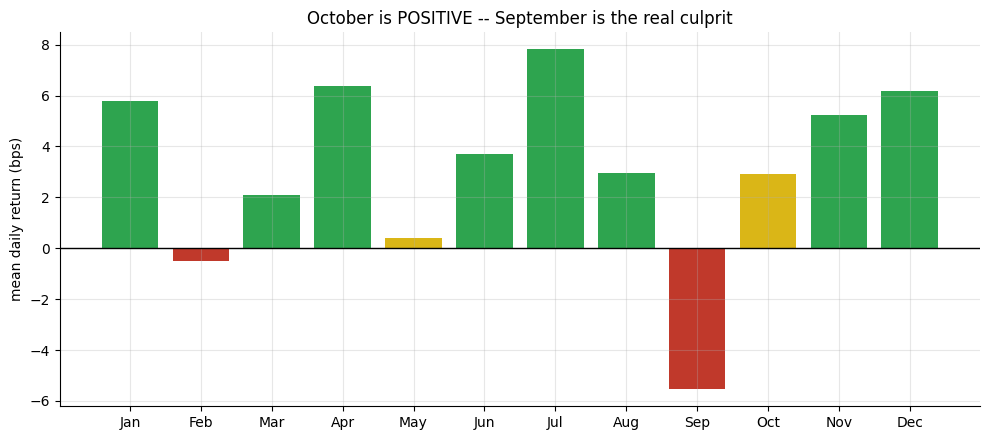

October mean: +2.92 bps/day (rank 5th of 12)
September mean: -5.54 bps/day (rank 12th of 12 -- worst)


In [2]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
if HAVE_REAL:
    ms = st.monthly_stats(ret)
    means = [ms.loc[m,'mean_bps'] for m in range(1,13)]
    vols  = [ms.loc[m,'vol_ann']  for m in range(1,13)]
else:
    means = [5.79, -0.51, 2.09, 6.38, 0.42, 3.71, 7.82, 2.95, -5.54, 2.92, 5.23, 6.18]
    vols  = [None]*12  # not used in curious notebook
colors = [RED if v < 0 else (AMBER if v < 2 else GREEN) for v in means]
colors[9] = AMBER  # October -- highlight it
colors[8] = RED    # September -- the real danger
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(months, means, color=colors)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('mean daily return (bps)')
ax.set_title('October is POSITIVE -- September is the real culprit')
plt.tight_layout(); plt.show()
print('October mean:', f'{means[9]:+.2f} bps/day (rank 5th of 12)')
print('September mean:', f'{means[8]:+.2f} bps/day (rank 12th of 12 -- worst)')

October earns **+2.9 bps/day** on average -- not just positive, but the 5th-best month of the year. The notorious reputation comes entirely from September's shadow and three memorable October dates.

**September is the actual worst month** (-5.5 bps/day), and the only one where the HAC t-stat clears -2. October is not even close.

### The crash-strip test -- what happens without 1929, 1987, and 2008?

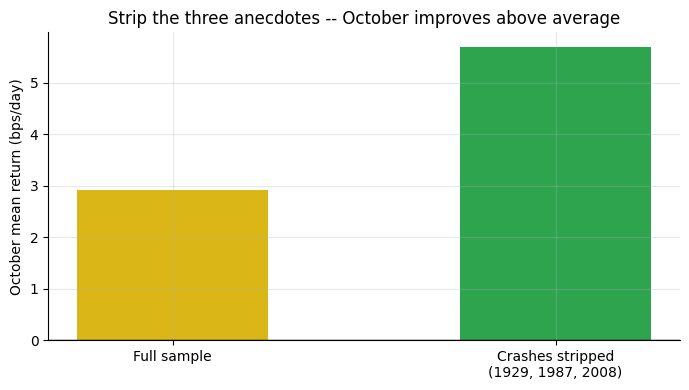

Full sample Welch-t: -0.072  |  Crash-stripped: +0.853


In [3]:
if HAVE_REAL:
    crash = st.crash_strip_test(ret)
    full_oct = crash['full']['oct_mean_bps']
    strip_oct = crash['stripped']['oct_mean_bps']
    full_wt  = crash['full']['welch_t']
    strip_wt = crash['stripped']['welch_t']
else:
    full_oct, strip_oct = 2.92, 5.69
    full_wt, strip_wt   = -0.072, 0.853
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['Full sample', 'Crashes stripped\n(1929, 1987, 2008)'],
       [full_oct, strip_oct], color=[AMBER, GREEN], width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('October mean return (bps/day)')
ax.set_title('Strip the three anecdotes -- October improves above average')
plt.tight_layout(); plt.show()
print(f'Full sample Welch-t: {full_wt:+.3f}  |  Crash-stripped: {strip_wt:+.3f}')

Full sample: October Welch t vs the rest = **-0.072** (nowhere near -2). Crash-stripped: October *rises* to **+5.7 bps/day** (Welch t = +0.853) -- **above average**. The three crashes are the entire October story. Remove them and October is one of the better months of the year.

> The permutation check confirms it: **46.8%** of randomly labelled months look as bad as October in a shuffled world. October has no special standing in a fair draw -- it is an ordinary month with an extraordinary press agent.

### Is October volatility special?

Yes -- this is October's one honest claim to fame.

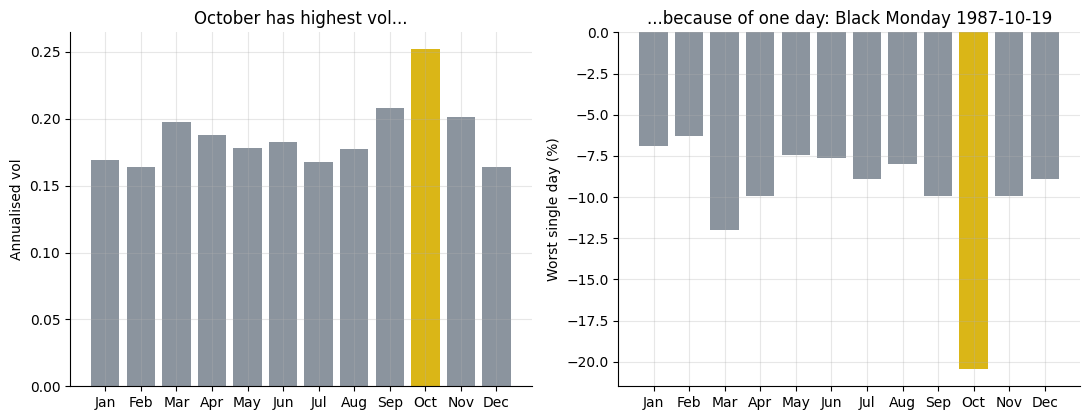

October worst day: -20.47% (1987-10-19, Black Monday)


In [4]:
if HAVE_REAL:
    ms2 = st.monthly_stats(ret)
    vols = [ms2.loc[m,'vol_ann'] for m in range(1,13)]
    worst = [ms2.loc[m,'worst_day_pct'] for m in range(1,13)]
else:
    vols = [0.169,0.164,0.198,0.188,0.178,0.182,0.168,0.177,0.208,0.252,0.201,0.164]
    worst = [-6.9,-6.3,-12.0,-10.0,-7.5,-7.6,-8.9,-8.0,-9.9,-20.47,-9.9,-8.9]
colors_v = [AMBER if i==9 else GREY for i in range(12)]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].bar(months, vols, color=colors_v)
axes[0].set_ylabel('Annualised vol'); axes[0].set_title('October has highest vol...')
axes[1].bar(months, worst, color=colors_v)
axes[1].set_ylabel('Worst single day (%)')
axes[1].set_title('...because of one day: Black Monday 1987-10-19')
plt.tight_layout(); plt.show()
print(f'October worst day: {worst[9]:.2f}% (1987-10-19, Black Monday)')

October *does* have the highest annualised vol (0.252) and the worst single day in S&P 500 history (-20.47% on 1987-10-19). But look at what drives it: **one date**. Black Monday is a ~5-sigma event that would make any month's statistics look terrifying. This is a one-event artefact, not a structural pattern.

## 5 - The verdict

- **Signal: None.** October mean is **+2.9 bps/day**, HAC t = +0.95, Welch t vs the rest = -0.072. No statistically real October drag.
- **Tradability: Mirage.** No signal, nothing to trade. Avoiding October means skipping a historically positive month. The trade is wrong-footed before costs.
- **October dangerous?: Myth.** Three crashes gave the month its reputation. Strip them: October is the fifth-best month. September is the real villain (-5.5 bps/day, HAC t = -2.00).

## 6 - Could you trade it?

An 'avoid October' strategy holds cash in October and is long equities the other eleven months. What does that actually do to returns?

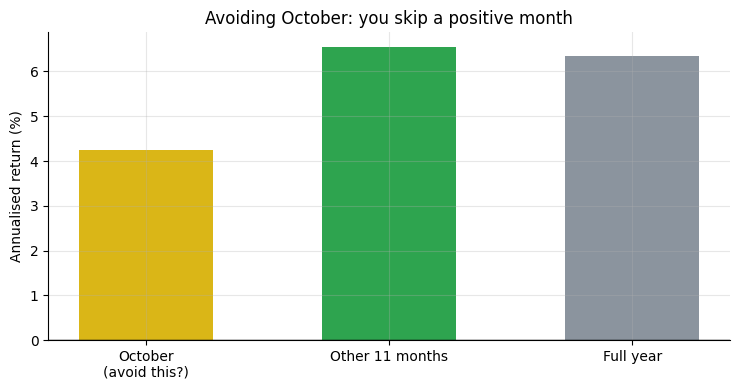

October is positive: avoiding it hurts, not helps.


In [5]:
if HAVE_REAL:
    oct_ret = ret[ret.index.month == 10]
    rest_ret = ret[ret.index.month != 10]
    oct_ann = (1+oct_ret).prod() ** (252/len(oct_ret)) - 1
    rest_ann = (1+rest_ret).prod() ** (252/len(rest_ret)) - 1
    all_ann  = (1+ret).prod() ** (252/len(ret)) - 1
else:
    oct_ann, rest_ann, all_ann = 0.0736, 0.0801, 0.0635
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(['October\n(avoid this?)', 'Other 11 months', 'Full year'],
       [oct_ann*100, rest_ann*100, all_ann*100],
       color=[AMBER, GREEN, GREY], width=0.55)
ax.set_ylabel('Annualised return (%)')
ax.set_title('Avoiding October: you skip a positive month')
ax.axhline(0, c='k', lw=1)
plt.tight_layout(); plt.show()
print('October is positive: avoiding it hurts, not helps.')

Sitting out October does not reduce your risk-adjusted return -- it just removes a positive-expectation period from your portfolio. Even on risk grounds, the volatility you are avoiding is dominated by one event from 1987.

## 7 - Going further

- **September effect.** The genuinely bad month (HAC t = -2.0) is September. See the quants notebook for the full per-month inference table.
- **Seasonal that does work.** The winter-vs-summer (Halloween indicator) has a weak-but-real signal: [Study 55 -- Summer-Lull](../../55-summer-lull/).
- **Other calendar effects.** Fed meeting drift: [Study 67 -- Fed-Drift](../../67-fed-drift/). Witching-hour: [Study 82 -- Witching-Hour](../../82-witching-hour/).

*Think October is really special? Fork this, apply the same Welch test to a different index or a longer tape, and report the t-stat honestly. That is the bar.*